## Importing Libraries, Data and Warnings


In [7]:
#importing libraries
#in the terminal write it as pip install (library to install)
import pandas as pd #write this so code recognises pd
import seaborn as sns
import matplotlib.pyplot as plt

#import warnings
import warnings
warnings.simplefilter("ignore", category=FutureWarning)
warnings.simplefilter("ignore", category=DeprecationWarning)


#import data
store=pd.read_csv("Rossman_store.csv")
train=pd.read_csv("Rossman_train.csv") #there is a mix type in column 7

/tmp/ipykernel_4250/41947671.py:15: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train=pd.read_csv("Rossman_train.csv") #there is a mix type in column 7


## Store Data

In [23]:
store.shape

(1115, 10)

In [24]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [25]:
store.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


In [26]:
#fill in missing values

#filled missing values with median
store["CompetitionDistance"]=store["CompetitionDistance"].fillna(store["CompetitionDistance"].median())

#fill in any missing years and months with 0
store["CompetitionOpenSinceMonth"]=store["CompetitionOpenSinceMonth"].astype("Int64")
store["CompetitionOpenSinceYear"]=store["CompetitionOpenSinceYear"].astype("Int64")

#the store does not have values for promo 2 and promo interval so fill in missing values with 0
store["Promo2SinceWeek"]=store["Promo2SinceWeek"].astype("Int64")
store["Promo2SinceYear"]=store["Promo2SinceYear"].astype("Int64")
store["PromoInterval"]=store["PromoInterval"].fillna("None")

In [28]:
#change the store type and assortment as categorical data
store["StoreType"] = store["StoreType"].astype("category")
store["Assortment"] = store["Assortment"].astype("category")

In [ ]:
store.to_csv("store_cleaned.csv", index=False)

## Training Data

In [ ]:
train.shape

(1017209, 9)

In [ ]:
train.head

<bound method NDFrame.head of          Store  DayOfWeek        Date  Sales  Customers  Open  Promo  \
0            1          5  2015-07-31   5263        555     1      1   
1            2          5  2015-07-31   6064        625     1      1   
2            3          5  2015-07-31   8314        821     1      1   
3            4          5  2015-07-31  13995       1498     1      1   
4            5          5  2015-07-31   4822        559     1      1   
...        ...        ...         ...    ...        ...   ...    ...   
1017204   1111          2  2013-01-01      0          0     0      0   
1017205   1112          2  2013-01-01      0          0     0      0   
1017206   1113          2  2013-01-01      0          0     0      0   
1017207   1114          2  2013-01-01      0          0     0      0   
1017208   1115          2  2013-01-01      0          0     0      0   

        StateHoliday  SchoolHoliday  
0                  0              1  
1                  0         

In [ ]:
train.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [ ]:
#Add dates
train["Date"]=pd.to_datetime(train["Date"])

In [ ]:
#changing state holiday to a categorical data typr
train["StateHoliday"] = train["StateHoliday"].astype("category")

In [ ]:
#half = len(train) // 2
#train = train.iloc[:half]   #dropping the bottom 50% of the training rows

In [ ]:
train.to_csv("train_cleaned.csv", index=False)

## Merging Data

In [ ]:
#merging the training and store data along the store index
merged = train.merge(store, on="Store", how="left")
merged.to_csv("merged.csv", index=False)

## Temp - Training Data but with removal of sales with 0

In [ ]:
temp = pd.read_csv("Rossman_train.csv", dtype={"StateHoliday": str})

zero_sales = (temp["Sales"] == 0).sum()
print(zero_sales) #17ish% is removed in this data

#this will drop the rows with 0 sales by saving temp with only rows with sales!=0
temp = temp[temp["Sales"] != 0]

merged_2 = temp.merge(store, on="Store", how="left")

172871


## Distribution of Sales - Temp Data

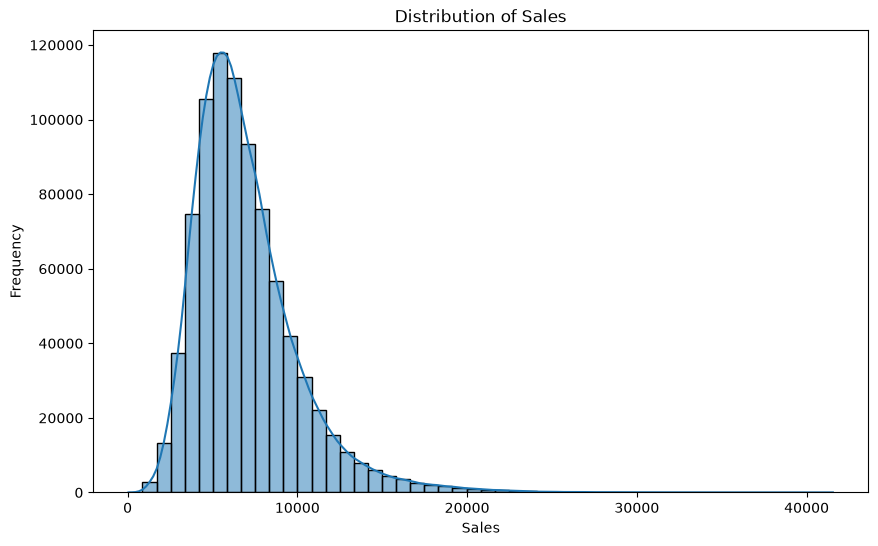

In [ ]:
#this has not been saved as a csv because we rnt sure if we will use this yet
# EDA for the temp data
plt.figure(figsize=(10,6))

sns.histplot(merged_2["Sales"], bins=50, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

## Sales by day of the Week

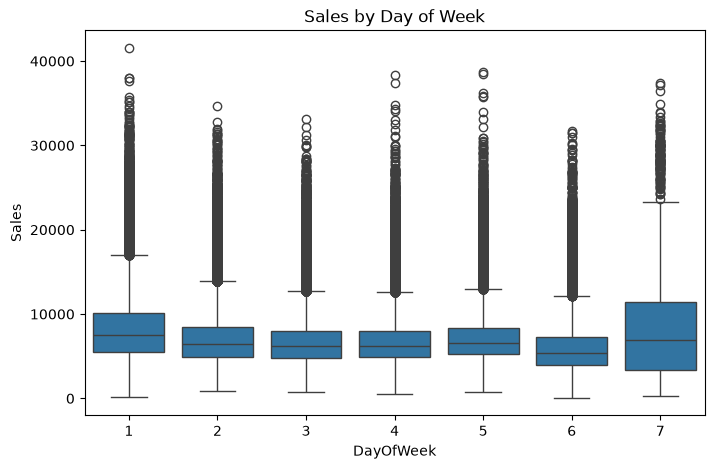

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=merged_2,
    x="DayOfWeek",
    y="Sales"
)

plt.title("Sales by Day of Week")

plt.show()